# qspin — tutorial

This notebook walks through the typical workflow of the `qspin` package on
a single dataset:

1. load and gauge-fix the data;
2. fit the **pseudo-likelihood** (PL) inverse Ising, Blume–Capel (BC) and
   Blume–Emery–Griffiths (BEG) models;
3. refine via **persistent contrastive divergence** (PCD), warm-starting
   from the PL solution;
4. **sample** synthetic data from each inferred model with MCMC;
5. plot **diagnostic figures** comparing the empirical and the
   model-generated marginals, second moments and distances.

The whole notebook is configured to run end-to-end on small toy data in a few
seconds.  To reproduce a paper-quality fit, switch to a real questionnaire
dataset and bump the iteration / sample counts in the `CONFIG` cell below.

## 0. Setup

In [3]:
# %matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import qspin
from qspin import (
    gaugefixing_data,
    # pseudo-likelihood inference
    generalizedIsing_inference,
    generalizedBC_inference,
    generalizedBEG_inference,
    # PCD inference
    generalizedIsing_inferencePCD,
    generalizedBC_inferencePCD,
    generalizedBEG_inferencePCD,
    # MCMC wrappers
    mcmc_ising,
    mcmc_beg,
    # sampling utilities
    sample_configurations_likelearning,
)
from qspin.figures import DEFAULT_COLORS, DEFAULT_CFG

np.random.seed(42)
print('qspin version:', qspin.__version__)

qspin version: 0.1.0


## 1. Data

For this tutorial we use a **synthetic** Q=3 dataset drawn from a known
Blume–Capel model, so we can later check that the inferred parameters are
close to the planted ones.

If you have a real questionnaire dataset on disk (e.g. one of the
data sources supported by `qspin.data.load_data`), replace this section with:

```python
from qspin import data
X_raw = data.load_data('big5', pathdata='/path/to/datasets/')
Q = len(set(X_raw.flatten()))
```

and skip the synthetic-data generator.

In [4]:
# ---- synthetic-data parameters
M = 8        # number of items
Q = 3        # number of spin states (Likert levels)
N = 2000     # number of subjects

# planted parameters
J_true = 0.4 * np.random.randn(M, M)
J_true = 0.5 * (J_true + J_true.T)
np.fill_diagonal(J_true, 0.6 * np.random.randn(M))   # BC anisotropy term
h_true = 0.3 * np.random.randn(M)

# Draw data by MCMC sampling from the BC model
states = qspin.possible_states(Q)
sigmas0 = np.random.choice(states, size=M)
synthetic = qspin.mcmc_ising(J_true, h_true, Q=Q, anisotropy=True)
synthetic.thermalize(betai=0., betaf=1., nsweeps=300, iicc='random', nb_chunks=30)

X = np.zeros((N, M), dtype=int)
for n in range(N):
    obs, _ = synthetic.sample(beta=1., nsweeps_sampling=5)
    X[n] = synthetic.sigmas

print('Synthetic data shape:', X.shape, ' alphabet:', sorted(set(X.flatten())))

Synthetic data shape: (2000, 8)  alphabet: [np.int64(-1), np.int64(0), np.int64(1)]


## 2. Gauge-fixing

The inverse models expect zero-sum spin states. Real datasets typically come
in coded as ``{1, 2, ..., Q}``; for Q=3 that becomes ``{-1, 0, 1}`` after
gauge fixing. The synthetic data is already in the gauge-fixed alphabet, so
calling ``gaugefixing_data`` is a no-op here.

In [5]:
X_gf = gaugefixing_data(X, Q)
print('Gauge-fixed alphabet:', sorted(set(X_gf.flatten())))
print('Mean per item:', X_gf.mean(axis=0).round(3))

Gauge-fixed alphabet: [np.int64(-1), np.int64(0), np.int64(1)]
Mean per item: [ 0.09  -0.313  0.5   -0.207 -0.306 -0.188 -0.233  0.411]


## 3. Pseudo-likelihood inference

The PL classes optimize the conditional log-likelihood
$$
\mathcal{L}_{\text{PL}}(\theta) = \sum_{s,i} \log P_\theta(x^{(s)}_i \mid x^{(s)}_{\setminus i})
$$
with L-BFGS-B, which is fast but biased relative to true ML.  We use it as a
warm start for PCD below.

In [6]:
# Ising  (diag(J) = 0)
pl_ising = generalizedIsing_inference(Q=Q, l2_lambda=1e-2)
J_pli, h_pli = pl_ising.fit(X_gf, verbose=False)

# Blume--Capel  (diag(J) free, anisotropy term)
pl_bc = generalizedBC_inference(Q=Q, l2_lambda=1e-2)
J_plbc, h_plbc = pl_bc.fit(X_gf, verbose=False)

# Blume--Emery--Griffiths  (adds biquadratic K)
pl_beg = generalizedBEG_inference(Q=Q, l2_lambda=1e-2)
J_plbeg, h_plbeg, K_plbeg = pl_beg.fit(X_gf, verbose=False)

print('per-sample log-pseudolikelihoods (training):')
print(f'  Ising : {pl_ising.loglikelihood(X_gf):.4f}')
print(f'  BC    : {pl_bc.loglikelihood(X_gf):.4f}')
print(f'  BEG   : {pl_beg.loglikelihood(X_gf):.4f}')

per-sample log-pseudolikelihoods (training):
  Ising : -7.3532
  BC    : -7.2902
  BEG   : -7.2791


### A quick sanity check

For the BC model, the inferred couplings should track the planted ones (up
to noise from finite N).

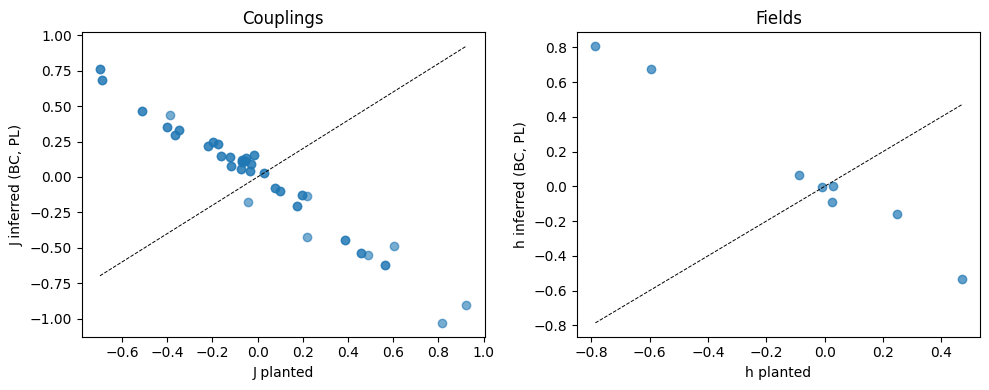

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].plot(J_true.flatten(), J_plbc.flatten(), 'o', alpha=0.6)
axs[0].plot([J_true.min(), J_true.max()], [J_true.min(), J_true.max()], 'k--', lw=0.7)
axs[0].set_xlabel('J planted'); axs[0].set_ylabel('J inferred (BC, PL)')
axs[0].set_title('Couplings')

axs[1].plot(h_true, h_plbc, 'o', alpha=0.7)
axs[1].plot([h_true.min(), h_true.max()], [h_true.min(), h_true.max()], 'k--', lw=0.7)
axs[1].set_xlabel('h planted'); axs[1].set_ylabel('h inferred (BC, PL)')
axs[1].set_title('Fields')

plt.tight_layout(); plt.show()

## 4. PCD refinement

Persistent contrastive divergence runs ``ncopies`` parallel Gibbs chains
and updates the parameters by Adam. The chains are *persistent*: between
two gradient updates they only run for ``tau_PCD`` Gibbs sweeps, but they
are never restarted (unless ``tau_c`` is set).

We warm-start from the PL solution to get a head start on convergence.

In [8]:
# small budget for tutorial speed; bump these to reach paper-quality fits
NITER, LR    = 50, 1e-3
NCOPIES      = 30
TAU_PCD      = 20
TAU_THERM    = 20

pcd_ising = generalizedIsing_inferencePCD(Q=Q, l2_lambda=0.)
J_pcd_i, h_pcd_i = pcd_ising.naif_fit_euler(
    X_gf,
    niterations=NITER, learning_rate=LR,
    ncopies=NCOPIES, tau_PCD=TAU_PCD, tau_therm=TAU_THERM,
    iicc='given', J0=J_pli, h0=h_pli, verbose=False)

pcd_bc = generalizedBC_inferencePCD(Q=Q, l2_lambda=0.)
J_pcd_bc, h_pcd_bc = pcd_bc.naif_fit_euler(
    X_gf,
    niterations=NITER, learning_rate=LR,
    ncopies=NCOPIES, tau_PCD=TAU_PCD, tau_therm=TAU_THERM,
    iicc='given', J0=J_plbc, h0=h_plbc, verbose=False)

pcd_beg = generalizedBEG_inferencePCD(Q=Q, l2_lambda=0.)
J_pcd_beg, h_pcd_beg, K_pcd_beg = pcd_beg.naif_fit_euler(
    X_gf,
    niterations=NITER, learning_rate=LR,
    ncopies=NCOPIES, tau_PCD=TAU_PCD, tau_therm=TAU_THERM,
    iicc='given', J0=J_plbeg, h0=h_plbeg, K0=K_plbeg, verbose=False)

print('PCD done.')

100%|██████████| 50/50 [00:02<00:00, 18.91it/s]

PCD done.


### PCD loss curves

Each PCD class stores per-iteration losses in ``self.losses``:

- column 0 : per-sample log pseudo-likelihood (monitor only);
- column 1 : $L_{\mathbf{h}} = \|\langle \mathbf{x} \rangle_{\text{data}} - \langle \mathbf{x} \rangle_{\text{model}}\|^2$;
- column 2 : $L_{J} = \|\langle \mathbf{x}\mathbf{x}^\top \rangle_{\text{data}} - \langle \mathbf{x}\mathbf{x}^\top \rangle_{\text{model}}\|^2$;
- column 3 : $L_K$ (BEG only).

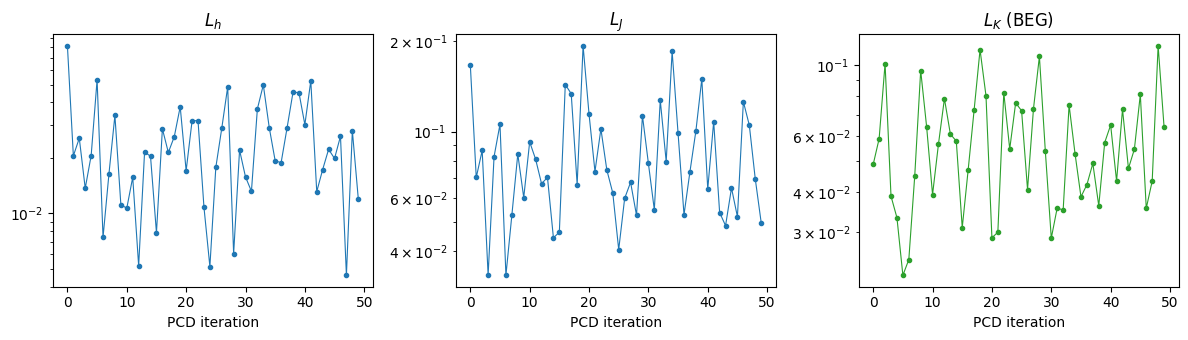

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, lab, losses, col in zip(
    axs,
    [r'$L_h$', r'$L_J$', r'$L_K$ (BEG)'],
    [pcd_ising.losses[:, 1], pcd_ising.losses[:, 2], pcd_beg.losses[:, 3]],
    ['ising', 'ising', 'beg'],
):
    ax.plot(losses, '.-', color=DEFAULT_COLORS[col], lw=0.8)
    ax.set_xlabel('PCD iteration')
    ax.set_title(lab)
    ax.set_yscale('log')
plt.tight_layout(); plt.show()

## 5. Sampling from the inferred models

The MCMC wrapper takes the parameters in the *energy* sign convention; the
inverse-Ising classes return them in the *log-likelihood* sign convention.
So we pass ``-J_fit``, ``-h_fit``, ``-K_fit``.

In [10]:
NCONF, TAU_C = 2000, 50       # tutorial budget; the paper uses 10^6 / 1000

# --- Ising sampler ---
mc_i = mcmc_ising(-pcd_ising.J_fit, -pcd_ising.h_fit, Q=Q)
mc_i.thermalize(betai=0., betaf=1., nsweeps=200, iicc='random', nb_chunks=20)
sim_i = sample_configurations_likelearning(
    mc_i, X=X_gf, states=pcd_ising.states,
    N_configurations=NCONF, n_intersample_sweeps=TAU_C, reset='emp')

# --- BC sampler (same wrapper class, anisotropy=True) ---
mc_bc = mcmc_ising(-pcd_bc.J_fit, -pcd_bc.h_fit, Q=Q, anisotropy=True)
mc_bc.thermalize(betai=0., betaf=1., nsweeps=200, iicc='random', nb_chunks=20)
sim_bc = sample_configurations_likelearning(
    mc_bc, X=X_gf, states=pcd_bc.states,
    N_configurations=NCONF, n_intersample_sweeps=TAU_C, reset='emp')

# --- BEG sampler ---
mc_beg = mcmc_beg(-pcd_beg.J_fit, -pcd_beg.h_fit, -pcd_beg.K_fit, Q=Q)
mc_beg.thermalize(betai=0., betaf=1., nsweeps=200, iicc='random', nb_chunks=20)
sim_beg = sample_configurations_likelearning(
    mc_beg, X=X_gf, states=pcd_beg.states,
    N_configurations=NCONF, n_intersample_sweeps=TAU_C, reset='emp')

print('sampled configurations: Ising', sim_i['configurations'].shape,
      'BC', sim_bc['configurations'].shape,
      'BEG', sim_beg['configurations'].shape)

sampled configurations: Ising (2000, 8) BC (2000, 8) BEG (2000, 8)


## 6. Moment matching

A maxent model fitted by maximum likelihood should reproduce the empirical
sufficient statistics. Below we check the per-item mean, the second moment,
and the off-diagonal covariance.

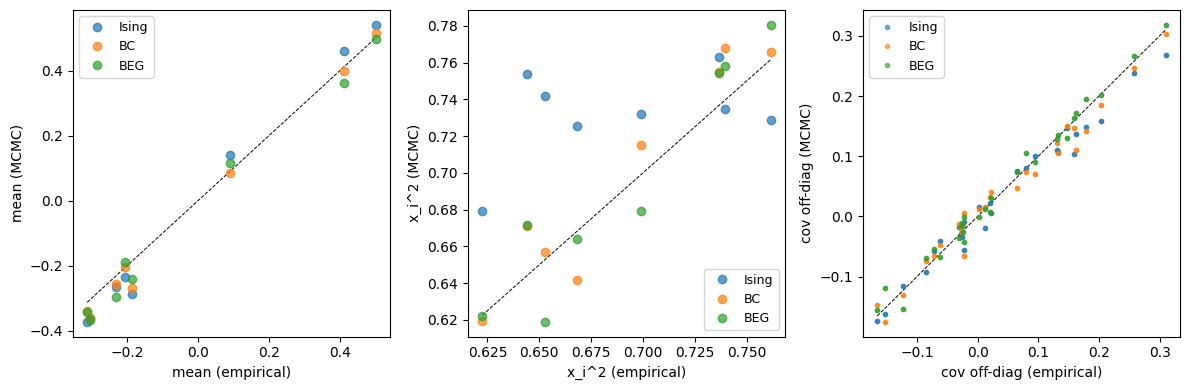

In [11]:
def _offdiag(M):
    n = M.shape[0]
    return M[~np.eye(n, dtype=bool)]

emp_mean = X_gf.mean(axis=0)
emp_x2   = (X_gf ** 2).mean(axis=0)
emp_cov  = _offdiag(np.cov(X_gf.T))

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
for ax, lab, e in zip(axs, ['mean', 'x_i^2', 'cov off-diag'], [emp_mean, emp_x2, emp_cov]):
    ax.plot([e.min(), e.max()], [e.min(), e.max()], 'k--', lw=0.7)
    ax.set_xlabel(lab + ' (empirical)')
    ax.set_ylabel(lab + ' (MCMC)')

for sim, lbl, col in [(sim_i, 'Ising', DEFAULT_COLORS['ising']),
                      (sim_bc, 'BC', DEFAULT_COLORS['bc']),
                      (sim_beg, 'BEG', DEFAULT_COLORS['beg'])]:
    C = sim['configurations']
    axs[0].plot(emp_mean, C.mean(axis=0), 'o', label=lbl, color=col, alpha=0.7)
    axs[1].plot(emp_x2, (C ** 2).mean(axis=0), 'o', label=lbl, color=col, alpha=0.7)
    axs[2].plot(emp_cov, _offdiag(np.cov(C.T)), 'o', label=lbl, color=col, alpha=0.6, ms=3)

for ax in axs:
    ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 7. Distance histograms (paper Figure 5/6)

The *Euclidean-distance-to-mean* histogram is a single-number summary of the
high-dimensional density: it highlights heavy tails that distinguish BEG
from Gaussian-like baselines.

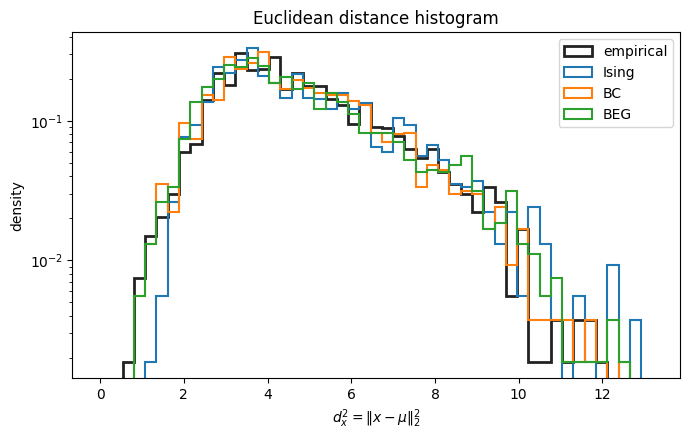

In [12]:
def _d2(C):
    return np.sum((C - C.mean(axis=0)) ** 2, axis=1)

d2_X   = _d2(X_gf)
d2_i   = _d2(sim_i['configurations'])
d2_bc  = _d2(sim_bc['configurations'])
d2_beg = _d2(sim_beg['configurations'])

fig, ax = plt.subplots(figsize=(7, 4.5))
bins = np.linspace(0, d2_X.max() * 1.1, 50)
ax.hist(d2_X, bins=bins, density=True, histtype='step', lw=2,
        color=DEFAULT_COLORS['emp'], label='empirical')
ax.hist(d2_i, bins=bins, density=True, histtype='step', lw=1.5,
        color=DEFAULT_COLORS['ising'], label='Ising')
ax.hist(d2_bc, bins=bins, density=True, histtype='step', lw=1.5,
        color=DEFAULT_COLORS['bc'], label='BC')
ax.hist(d2_beg, bins=bins, density=True, histtype='step', lw=1.5,
        color=DEFAULT_COLORS['beg'], label='BEG')
ax.set_yscale('log')
ax.set_xlabel(r'$d_x^2 = \|x - \mu\|_2^2$')
ax.set_ylabel('density')
ax.legend()
ax.set_title('Euclidean distance histogram')
plt.tight_layout(); plt.show()

## 8. Null-model baselines

`qspin.nullmodels` ships three simple baselines you can compare against:

- **categorical-independent** (`catind_model`): each item from its own marginal;
- **Gaussian-then-discretize** (`model_gaussdisc`): the full pairwise
  covariance, then per-item quantile discretization;
- **Gaussian copula** (`null_gaussian_copula`): Spearman-based copula then
  inverse empirical CDF.

In [13]:
from qspin import nullmodels

R = len(set(X_gf.flatten()))
Xn_cat   = nullmodels.catind_model(X_gf, R=R, N=NCONF)
Xn_gd    = nullmodels.model_gaussdisc(X_gf, R=R, N=NCONF)
# Copula expects non-negative integer codes; map back to {0,...,Q-1} first.
X_int    = X_gf - X_gf.min()
Xn_cop   = nullmodels.null_gaussian_copula(X_int, NCONF, X_int.shape[1], R, nfa=1)

print('null-model samples:', Xn_cat.shape, Xn_gd.shape, Xn_cop.shape)

null-model samples: (2000, 8) (2000, 8) (2000, 8)


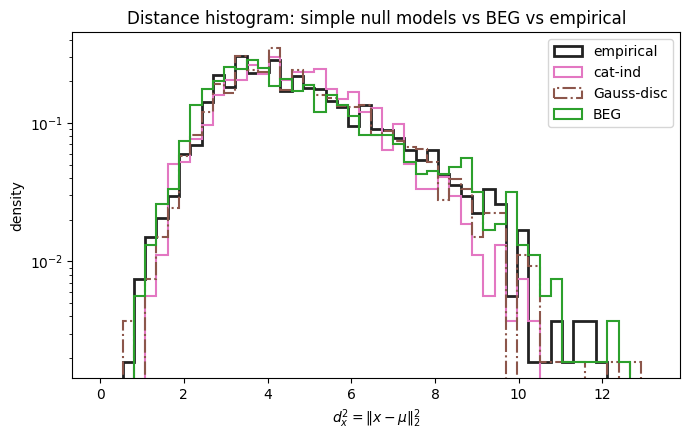

In [14]:
fig, ax = plt.subplots(figsize=(7, 4.5))
bins = np.linspace(0, d2_X.max() * 1.1, 50)
ax.hist(d2_X, bins=bins, density=True, histtype='step', lw=2,
        color=DEFAULT_COLORS['emp'], label='empirical')
ax.hist(_d2(Xn_cat), bins=bins, density=True, histtype='step', lw=1.5,
        color=DEFAULT_COLORS['nullcat'], label='cat-ind')
ax.hist(_d2(Xn_gd), bins=bins, density=True, histtype='step', lw=1.5,
        color=DEFAULT_COLORS['gaussdisc'], label='Gauss-disc', ls='-.')
ax.hist(d2_beg, bins=bins, density=True, histtype='step', lw=1.5,
        color=DEFAULT_COLORS['beg'], label='BEG')
ax.set_yscale('log')
ax.set_xlabel(r'$d_x^2 = \|x - \mu\|_2^2$')
ax.set_ylabel('density')
ax.set_title('Distance histogram: simple null models vs BEG vs empirical')
ax.legend()
plt.tight_layout(); plt.show()

## 9. Where to go from here

- The pre-made plotting helpers in `qspin.figures` (`plot_losses`,
  `plot_moment_matching_*`, `plot_item_histogram`, `plot_E2d_histogram_*`,
  `plot_mahalanobis_*`, `plot_pc_histogram_maxent`,
  `plot_correlation_time_analysis`) accept the *same* simulation
  dictionaries as the ones returned by `sample_configurations_likelearning`,
  provided you populate `dict_means`, `dict_stds`, `distances_maxent`,
  `energies_maxent_commonC`, `energies_maxent`, etc. on each `sim_*` dict.
  See `inverse_BEG-CD_all.py` for the full augmentation snippet used in the
  paper.
- For real datasets, switch `load_data(dataset, pathdata)` for one of the
  supported names (`pwe`, `big5`, `dass`, ...), and bump the iteration
  counts. The paper uses `niterations ~ 120 x 3`, `ncopies ~ 1000`,
  `N_configurations = 10^6`.
- To export the inferred model, just pickle the inference object: it stores
  `J_fit`, `h_fit`, (`K_fit`), and the loss history.